In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.shape

(1000, 3)

In [4]:
df.sample(5)

,cgpa,placement_exam_marks,placed
113,7.24,10.0,0
44,7.88,55.0,0
91,7.42,6.0,1
938,6.27,24.0,0
621,7.85,28.0,1


C:\Users\MY PC\AppData\Local\Temp\ipykernel_14404\2585408175.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'], color='blue')
C:\Users\MY PC\AppData\Local\Temp\ipykernel_14404\2585408175.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'], color='red')


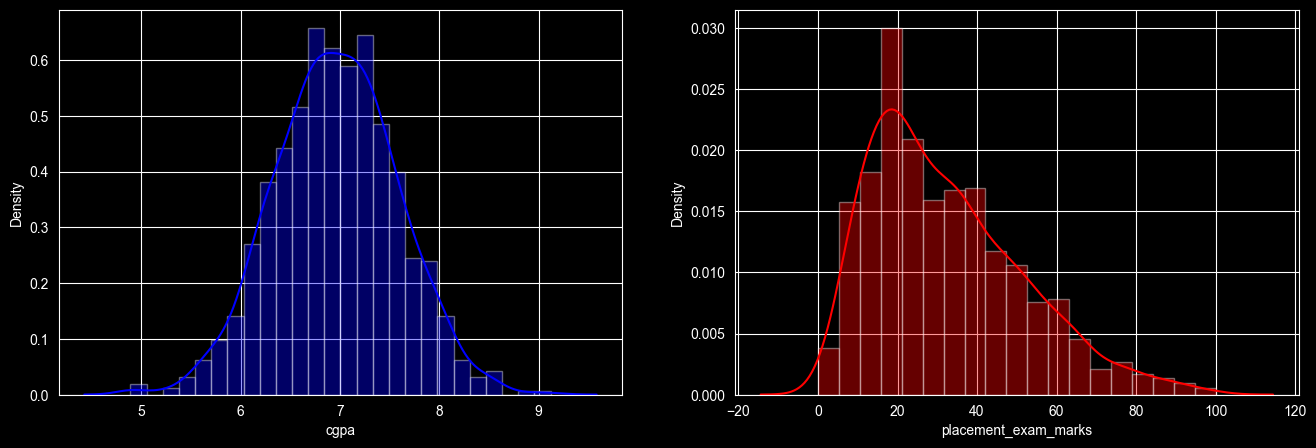

In [5]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'], color='blue')

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'], color='red')
plt.show()

In [6]:
df['cgpa'].skew()


np.float64(-0.014529938929314918)

In [7]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [8]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

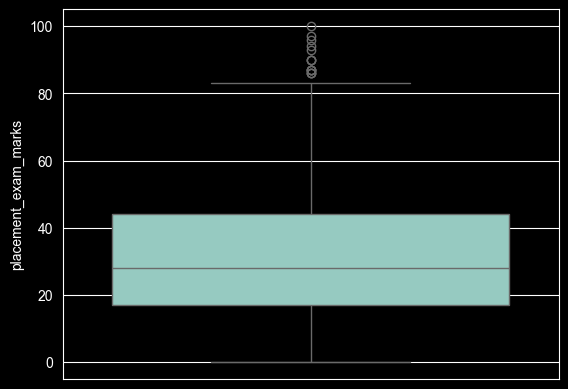

In [9]:
sns.boxplot(df['placement_exam_marks'])
plt.show()

In [10]:
# Finding IQR
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [11]:
percentile75

np.float64(44.0)

In [12]:
iqr = percentile75-percentile25

In [13]:
iqr

np.float64(27.0)

In [14]:
upper_limit = percentile75 + 1.5*iqr
lower_limit = percentile25 - 1.5*iqr

In [15]:
print("Upper limit: ", upper_limit)
print("Lower limit: ", lower_limit)

Upper limit:  84.5
Lower limit:  -23.5


# Finding outliers

In [16]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


# Trimming

In [17]:
new_df = df[df['placement_exam_marks'] < upper_limit]

In [19]:
new_df.shape

(985, 3)

C:\Users\MY PC\AppData\Local\Temp\ipykernel_14404\2128694079.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'], color='blue')
C:\Users\MY PC\AppData\Local\Temp\ipykernel_14404\2128694079.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['placement_exam_mark

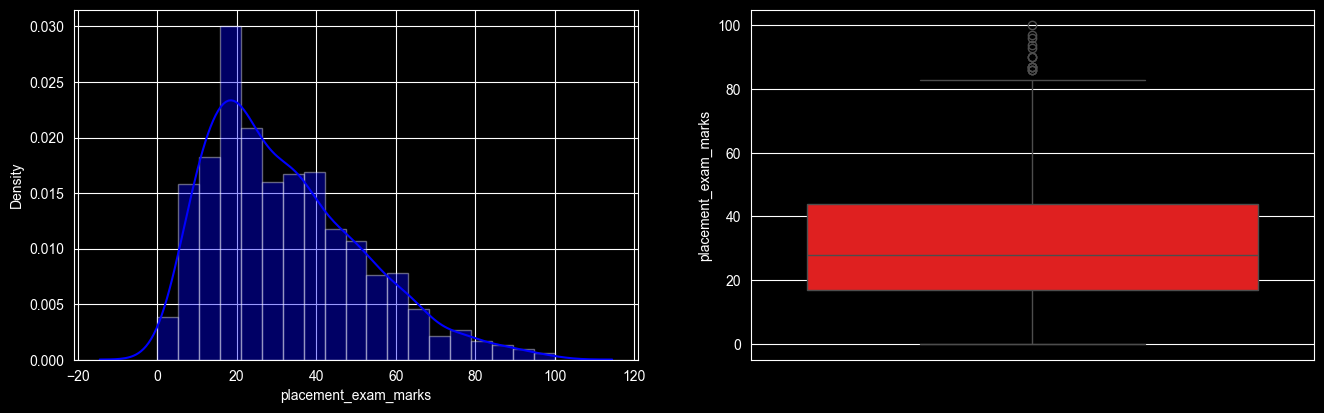

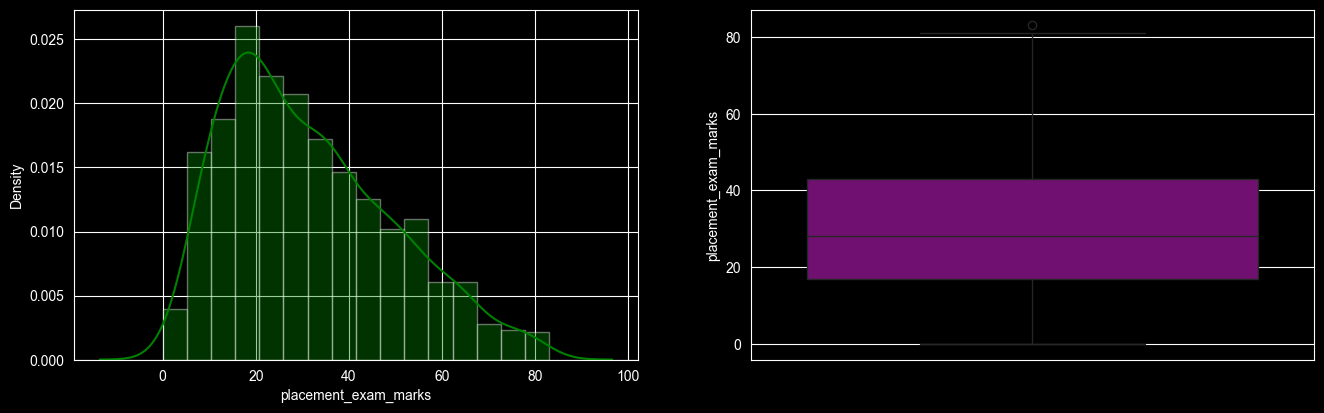

In [27]:
# Comparing
plt.figure(figsize=(16,10))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'], color='blue')

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'], color='red')

plt.figure(figsize=(16,10))
plt.subplot(2,2,3)
sns.distplot(new_df['placement_exam_marks'], color='green')

plt.subplot(2,2,4)
sns.boxplot(new_df['placement_exam_marks'], color='purple')
plt.show()

# Capping

In [28]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [30]:
new_df_cap.shape

(1000, 3)

C:\Users\MY PC\AppData\Local\Temp\ipykernel_14404\2709835339.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'], color='blue')
C:\Users\MY PC\AppData\Local\Temp\ipykernel_14404\2709835339.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap['placement_exam_

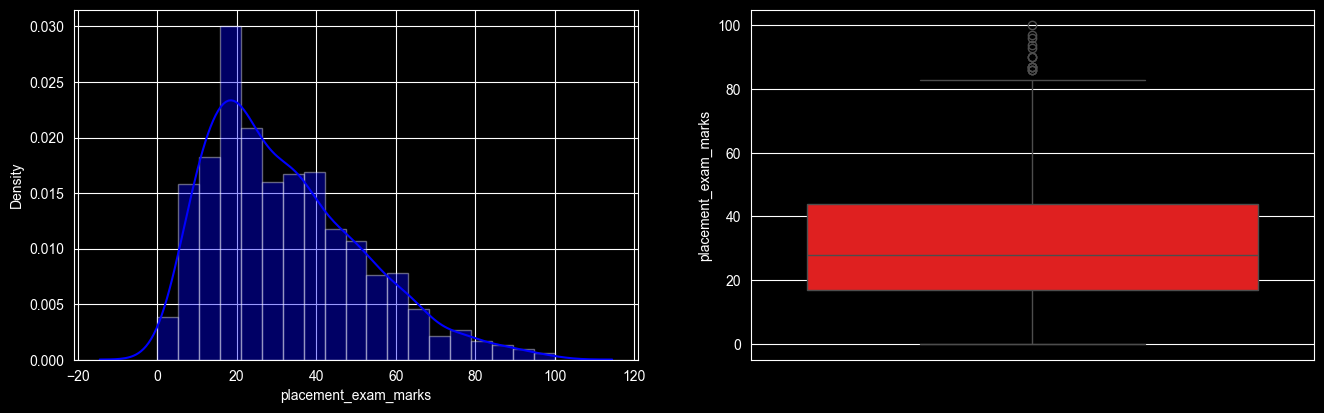

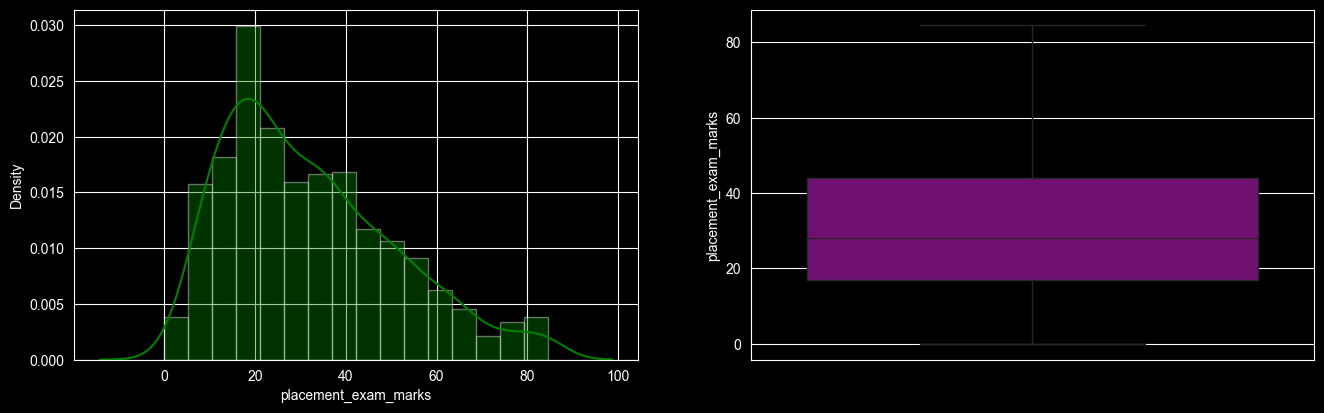

In [31]:
# Comparing
plt.figure(figsize=(16,10))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'], color='blue')

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'], color='red')

plt.figure(figsize=(16,10))
plt.subplot(2,2,3)
sns.distplot(new_df_cap['placement_exam_marks'], color='green')

plt.subplot(2,2,4)
sns.boxplot(new_df_cap['placement_exam_marks'], color='purple')
plt.show()